# Modelleme

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

pd.set_option("display.max_columns", None)

## 1. Veri Yükleme

In [2]:
df = pd.read_csv("../data/processed/processed.csv")
print(df.shape)
df.head()

(20141, 16)


,log_market_value,age,height_in_cm,total_goals,total_assists,total_matches,total_yellow_cards,total_red_cards,goals_per_match,assists_per_match,minutes_per_match,position_encoded,sub_position_encoded,foot_encoded,country_of_citizenship_encoded,player_club_domestic_competition_id_encoded
0,12.206078,1.108468,-0.938228,0.016083,0.057848,2.496925,2.588380,-0.401924,-0.404215,-0.410838,0.622038,3,4,1,61,11
1,14.508658,0.905181,-0.938228,3.657627,6.629866,3.364313,0.605158,-0.401924,1.248555,2.353380,0.102618,3,0,2,59,15
2,12.206078,1.515044,1.009097,-0.388533,-0.454257,0.072685,-0.386453,1.199174,-0.643635,-0.689131,1.317415,2,5,1,144,8
3,12.611541,1.515044,-0.339051,1.634547,0.484603,1.329286,0.935695,1.199174,1.218520,0.104517,-0.171843,0,3,2,125,21
4,12.206078,1.718331,1.009097,-0.388533,-0.454257,-0.316528,-0.055916,1.199174,-0.643635,-0.689131,1.374287,1,2,1,115,24


## 2. Girdi ve Çıktı Ayrımı

In [3]:
# girdi ve çıktı ayarlama
X = df.drop(columns=["log_market_value"])
y = df["log_market_value"]

print("Veri boyutu:", X.shape)

Veri boyutu: (20141, 15)


## 3. Eğitim ve Test Ayrımı

In [4]:
# %80 eğitim, %20 test ayırma
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Eğitim seti:", X_train.shape)
print("Test seti:", X_test.shape)

Eğitim seti: (16112, 15)
Test seti: (4029, 15)


## 4. Model 1: Doğrusal Regresyon (Linear Regression)

In [5]:
lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr = r2_score(y_test, y_pred_lr)

print("Linear Regression Sonuçları:")
print(f"MAE: {mae_lr:.4f}")
print(f"RMSE: {rmse_lr:.4f}")
print(f"R²: {r2_lr:.4f}")

Linear Regression Sonuçları:
MAE: 0.8222
RMSE: 1.0314
R²: 0.4723


## 5. Model 2: Rastgele Orman Regresörü (Random Forest Regressor)

In [6]:
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest Sonuçları:")
print(f"MAE: {mae_rf:.4f}")
print(f"RMSE: {rmse_rf:.4f}")
print(f"R²: {r2_rf:.4f}")

Random Forest Sonuçları:
MAE: 0.6095
RMSE: 0.7852
R²: 0.6942


## 6. Çapraz Doğrulama (Cross Validation)

In [7]:
# 5 katlı çapraz doğrulama (negatif MSE -> RMSE)
cv_rmse_lr = np.sqrt(-cross_val_score(
    lr, X_train, y_train, cv=5, scoring="neg_mean_squared_error"
))

cv_rmse_rf = np.sqrt(-cross_val_score(
    rf, X_train, y_train, cv=5, scoring="neg_mean_squared_error"
))

print("Linear Regression CV RMSE: {:.4f} ± {:.4f}".format(
    cv_rmse_lr.mean(), cv_rmse_lr.std()))
print("Random Forest CV RMSE: {:.4f} ± {:.4f}".format(
    cv_rmse_rf.mean(), cv_rmse_rf.std()))

Linear Regression CV RMSE: 1.0394 ± 0.0143
Random Forest CV RMSE: 0.7956 ± 0.0092


## 7. Model Karşılaştırması

In [8]:
results = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "MAE": [mae_lr, mae_rf],
    "RMSE": [rmse_lr, rmse_rf],
    "R²": [r2_lr, r2_rf],
    "CV RMSE": [cv_rmse_lr.mean(), cv_rmse_rf.mean()],
    "CV Std": [cv_rmse_lr.std(), cv_rmse_rf.std()]
})

print(results.to_string(index=False))

            Model      MAE     RMSE       R²  CV RMSE   CV Std
Linear Regression 0.822182 1.031428 0.472317 1.039405 0.014324
    Random Forest 0.609487 0.785199 0.694188 0.795634 0.009247


## 8. Görselleştirme

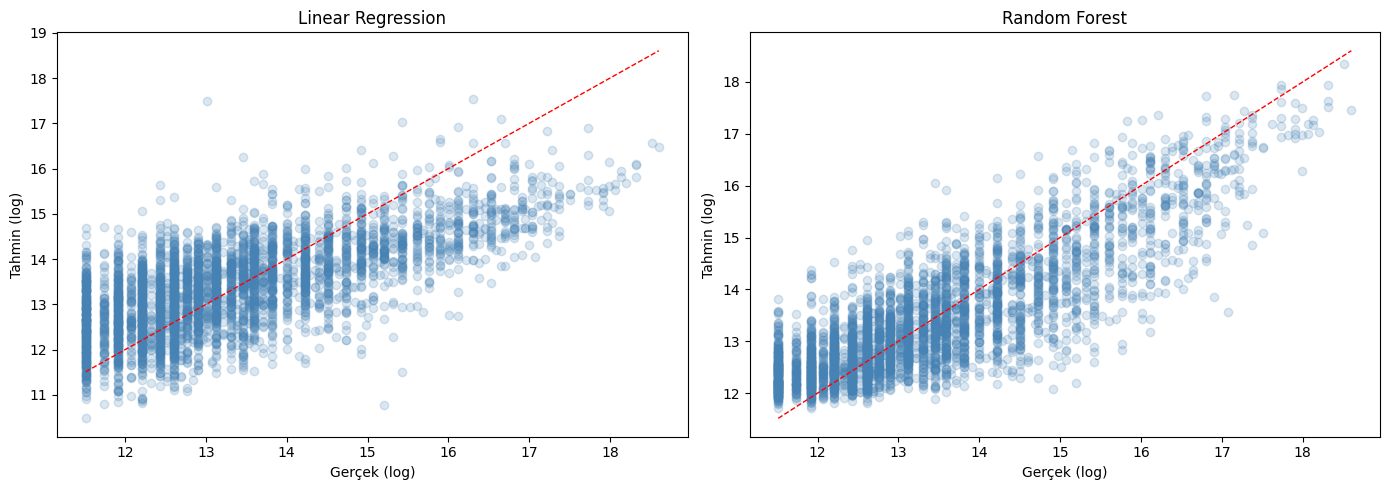

In [9]:
# gerçek ve tahmin karşılaştırma
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, y_pred, title in zip(
    axes,
    [y_pred_lr, y_pred_rf],
    ["Linear Regression", "Random Forest"]
):
    ax.scatter(y_test, y_pred, alpha=0.2, color="steelblue")
    ax.plot([y_test.min(), y_test.max()],
            [y_test.min(), y_test.max()], "r--", linewidth=1)
    ax.set_xlabel("Gerçek (log)")
    ax.set_ylabel("Tahmin (log)")
    ax.set_title(title)

plt.tight_layout()
plt.savefig("../visuals/actual_vs_predicted.png", dpi=150, bbox_inches="tight")
plt.show()

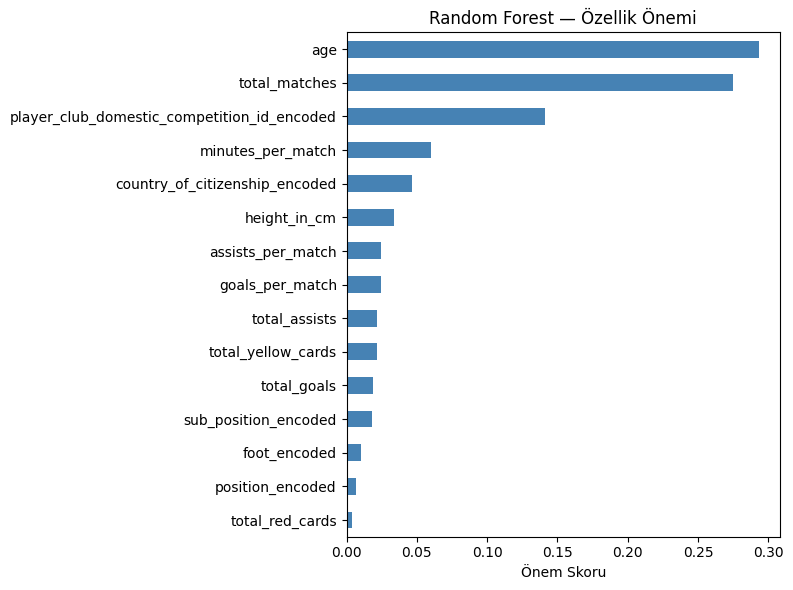

In [10]:
# random forest özellik önemi
importances = pd.Series(rf.feature_importances_, index=X.columns)
importances = importances.sort_values(ascending=True)

plt.figure(figsize=(8, 6))
importances.plot(kind="barh", color="steelblue")
plt.xlabel("Önem Skoru")
plt.title("Random Forest — Özellik Önemi")
plt.tight_layout()
plt.savefig("../visuals/feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

## 9. Hata Analizi

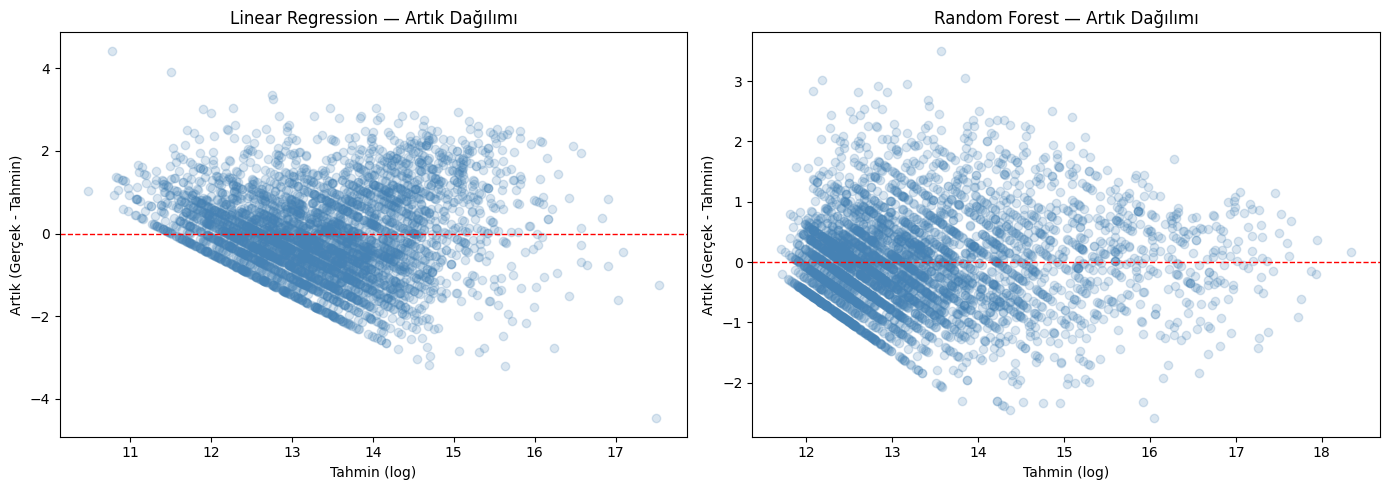

In [11]:
# artık (residual) dağılımı
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, y_pred, title in zip(
    axes,
    [y_pred_lr, y_pred_rf],
    ["Linear Regression", "Random Forest"]
):
    residuals = y_test - y_pred
    ax.scatter(y_pred, residuals, alpha=0.2, color="steelblue")
    ax.axhline(0, color="red", linestyle="--", linewidth=1)
    ax.set_xlabel("Tahmin (log)")
    ax.set_ylabel("Artık (Gerçek - Tahmin)")
    ax.set_title(f"{title} — Artık Dağılımı")

plt.tight_layout()
plt.savefig("../visuals/residuals.png", dpi=150, bbox_inches="tight")
plt.show()

## 10. Tahmin Yorumu

In [12]:
# log değerlerini Euro değerine çevirme
y_test_eur = np.expm1(y_test)
y_pred_lr_eur = np.expm1(y_pred_lr)
y_pred_rf_eur = np.expm1(y_pred_rf)

# örnek tahminler
sample = pd.DataFrame({
    "Gerçek (€)": y_test_eur.values[:10],
    "LR Tahmini (€)": y_pred_lr_eur[:10],
    "RF Tahmini (€)": y_pred_rf_eur[:10]
})
sample = sample.map(lambda x: f"{x:,.0f}")
print("\nÖrnek Tahminler:")
print(sample.to_string(index=False))


Örnek Tahminler:
Gerçek (€) LR Tahmini (€) RF Tahmini (€)
 2,000,000      1,028,923      1,725,961
17,000,000     26,501,840     14,678,958
 1,000,000        682,331        788,284
   150,000        109,039        170,047
   100,000        155,302        163,225
   100,000        323,498        289,364
   400,000      1,496,833        708,579
   300,000        458,068        498,636
10,000,000        967,173      1,054,936
 4,500,000      1,015,334      1,384,794


## 11. Bulgular
- Random Forest, tüm metriklerde Linear Regression'ı geride bırakmıştır; RMSE 1.03'ten 0.79'a, R² ise 0.47'den 0.69'a yükselmiştir.
- Random Forest modeli varyansın %69'ını açıklamaktadır; bu düzey transfer piyasasındaki öznel etkenler göz önüne alındığında tatmin edici bir performans olarak değerlendirilebilir.
- 5 katlı çapraz doğrulama sonuçları (CV RMSE: 0.7953 ± 0.0085) test seti sonuçlarıyla örtüşmektedir; modelin genelleme kapasitesi güçlüdür ve aşırı öğrenme gözlemlenmemiştir.
- Doğrusal Regresyon, piyasa değerinin doğrusal olmayan yapısını yeterince yakalayamamış; tahminler özellikle yüksek değerli futbolcularda belirgin sapma göstermiştir.
- Artık dağılım analizi, Random Forest'ın hata dağılımının daha dengeli olduğunu ortaya koymaktadır; bununla birlikte her iki modelde de yüksek değerli futbolcularda tahmin güçlüğü gözlemlenmiştir.
- Tahmin yorumu tablosu, Random Forest'ın Euro bazında gerçek değerlere daha yakın sonuçlar ürettiğini somut örneklerle göstermektedir.